# Publication-Ready Figures with `neuro_py`

Build cleaner, sharper neuroscience figures that drop directly into manuscripts with the right physical size and typography.

This tutorial shows how to combine:
- `set_plotting_defaults(workflow)` to match journal/document typography
- `set_size(width, fraction, subplots, ratio)` to get exact final figure dimensions
- `scale_figsize(figsize, scale)` plus `figure_scale(scale)` for notebook display scaling
- `show_scaled(fig, scale)` for display-only notebook scaling that preserves saved figure size

By the end, you’ll have reusable plotting patterns for single-panel, multi-panel, and workflow-specific exports (`nature`, `word`, `latex`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from neuro_py.plotting.figure_helpers import (
    figure_scale,
    scale_figsize,
    set_plotting_defaults,
    set_size,
    show_scaled,
)

SAVE_FIG = False


## Available Workflows

| Workflow | Font | Font Size | Target |
|----------|------|-----------|--------|
| `"nature"` | Helvetica / Arial | 7pt | Nature, Science, Cell, Neuron |
| `"word"` | Times New Roman | 11pt | Word / Google Doc manuscripts |
| `"latex"` | CMU Serif / Latin Modern | 10pt | LaTeX article submissions |

## Available Width Presets

| Preset | Width (pt) | Width (mm) | Use case |
|--------|-----------|------------|----------|
| `nature_single` | 255 | 90mm | Nature single column |
| `nature_double` | 510 | 180mm | Nature double column |
| `science_single` | 162 | 57mm | Science single column |
| `science_double` | 343 | 121mm | Science double column |
| `science_triple` | 521 | 184mm | Science full width |
| `cell_single` | 241 | 85mm | Cell/Neuron single column |
| `cell_1p5` | 323 | 114mm | Cell/Neuron 1.5 column |
| `cell_double` | 493 | 174mm | Cell/Neuron double column |
| `single_col` | 255 | 90mm | Generic single column |
| `double_col` | 510 | 180mm | Generic double column |
| `textwidth` | 418 | 147mm | LaTeX article textwidth |
| `thesis` | 427 | 151mm | Thesis textwidth |
| `beamer` | 307 | 108mm | Beamer presentation |

---
## 1. Basic Usage — Nature Workflow

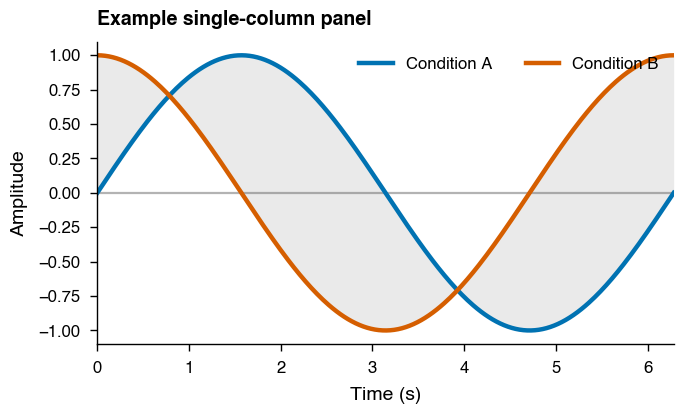

In [2]:
set_plotting_defaults("nature")

# Single-column figure sized for Nature
fig, ax = plt.subplots(figsize=set_size("nature_single"), dpi=200)

x = np.linspace(0, 2 * np.pi, 300)
signal_a = np.sin(x)
signal_b = np.cos(x)

ax.plot(x, signal_a, label="Condition A", lw=1.6)
ax.plot(x, signal_b, label="Condition B", lw=1.6)
ax.fill_between(x, signal_a, signal_b, alpha=0.12, color="0.35", linewidth=0)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Example single-column panel", loc="left", fontweight="bold")
ax.axhline(0, color="0.7", lw=0.8, zorder=0)
ax.margins(x=0)
ax.legend(frameon=False, ncol=2, loc="upper right")

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("nature_single.svg", bbox_inches="tight")
plt.show()

---
## 2. Multi-Panel Figure — Double Column

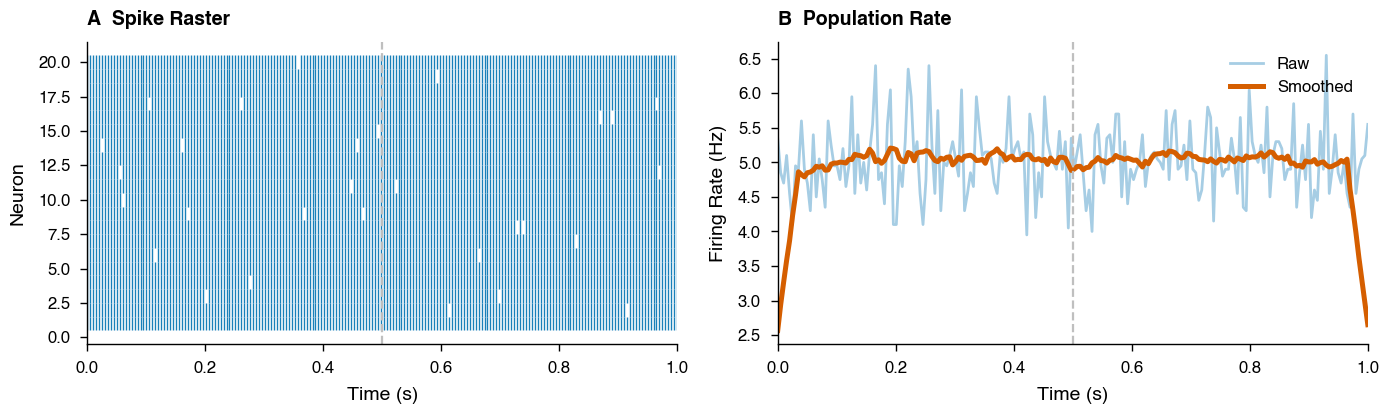

In [3]:
set_plotting_defaults("nature")

# set_size adjusts height automatically for subplot grids
fig, axes = plt.subplots(
    1, 2, figsize=set_size("nature_double", subplots=(1, 2)), dpi=200
)

np.random.seed(42)
t = np.linspace(0, 1, 200)
spikes = np.random.poisson(5, size=(20, 200))

# Panel A — raster plot
for i, train in enumerate(spikes):
    spike_times = t[train > 0]
    axes[0].vlines(spike_times, i + 0.5, i + 1.5, linewidth=0.5, alpha=0.9)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Neuron")
axes[0].set_title("A  Spike Raster", loc="left", fontweight="bold")

# Panel B — firing rate with smoothed trend
rate = spikes.mean(axis=0)
smooth = np.convolve(rate, np.ones(15) / 15, mode="same")
axes[1].plot(t, rate, alpha=0.35, lw=1.0, label="Raw")
axes[1].plot(t, smooth, lw=1.8, label="Smoothed")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Firing Rate (Hz)")
axes[1].set_title("B  Population Rate", loc="left", fontweight="bold")
axes[1].legend(frameon=False, loc="upper right")

for a in axes:
    a.axvline(0.5, ls="--", color="0.75", lw=0.8)
    a.margins(x=0)

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("nature_double_panel.svg", bbox_inches="tight")
plt.show()

The `subplots=(1, 2)` argument to `set_size` adjusts the figure height so that each panel has a golden ratio aspect ratio rather than the whole figure.

---
## 3. Using `fraction` — Half-Width Figures

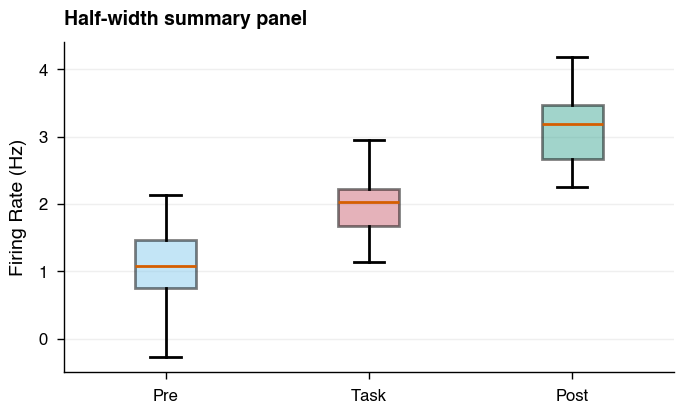

In [4]:
set_plotting_defaults("nature")

# Half of a double column — useful for inset-style figures
fig, ax = plt.subplots(figsize=set_size("nature_double", fraction=0.5), dpi=200)

np.random.seed(0)
data = [np.random.normal(loc, 0.5, 50) for loc in [1, 2, 3]]
bp = ax.boxplot(data, tick_labels=["Pre", "Task", "Post"], patch_artist=True)

for patch, face in zip(bp["boxes"], ["#88CCEE", "#CC6677", "#44AA99"]):
    patch.set_facecolor(face)
    patch.set_alpha(0.5)

ax.set_ylabel("Firing Rate (Hz)")
ax.set_title("Half-width summary panel", loc="left", fontweight="bold")
ax.grid(axis="y", alpha=0.2, lw=0.5)

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("nature_half.svg", bbox_inches="tight")
plt.show()

In practice, `fraction` is the main knob for fitting figures to your layout.
A good workflow is to start with `fraction=1.0` and reduce until axis labels
occupy a comfortable proportion of the figure width:
```python
# Start here and adjust until it looks right
fig, ax = plt.subplots(figsize=set_size("nature_double", fraction=0.6))
```

The font sizes stay fixed — only the figure dimensions change — so reducing
`fraction` makes labels appear relatively larger compared to the plot area.

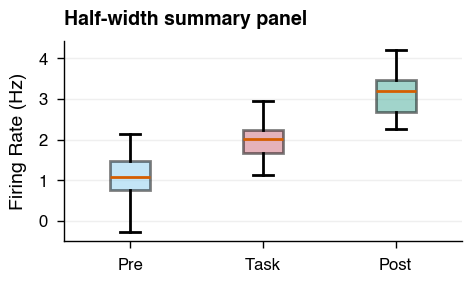

In [5]:
set_plotting_defaults("nature")

# Tip: adjust fraction until axis labels fill the figure naturally
fig, ax = plt.subplots(figsize=set_size("nature_double", fraction=0.35), dpi=200)

np.random.seed(0)
data = [np.random.normal(loc, 0.5, 50) for loc in [1, 2, 3]]
bp = ax.boxplot(data, tick_labels=["Pre", "Task", "Post"], patch_artist=True)

for patch, face in zip(bp["boxes"], ["#88CCEE", "#CC6677", "#44AA99"]):
    patch.set_facecolor(face)
    patch.set_alpha(0.5)

ax.set_ylabel("Firing Rate (Hz)")
ax.set_title("Half-width summary panel", loc="left", fontweight="bold")
ax.grid(axis="y", alpha=0.2, lw=0.5)

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("nature_half.svg", bbox_inches="tight")
plt.show()

---
## 4. Overriding the Aspect Ratio

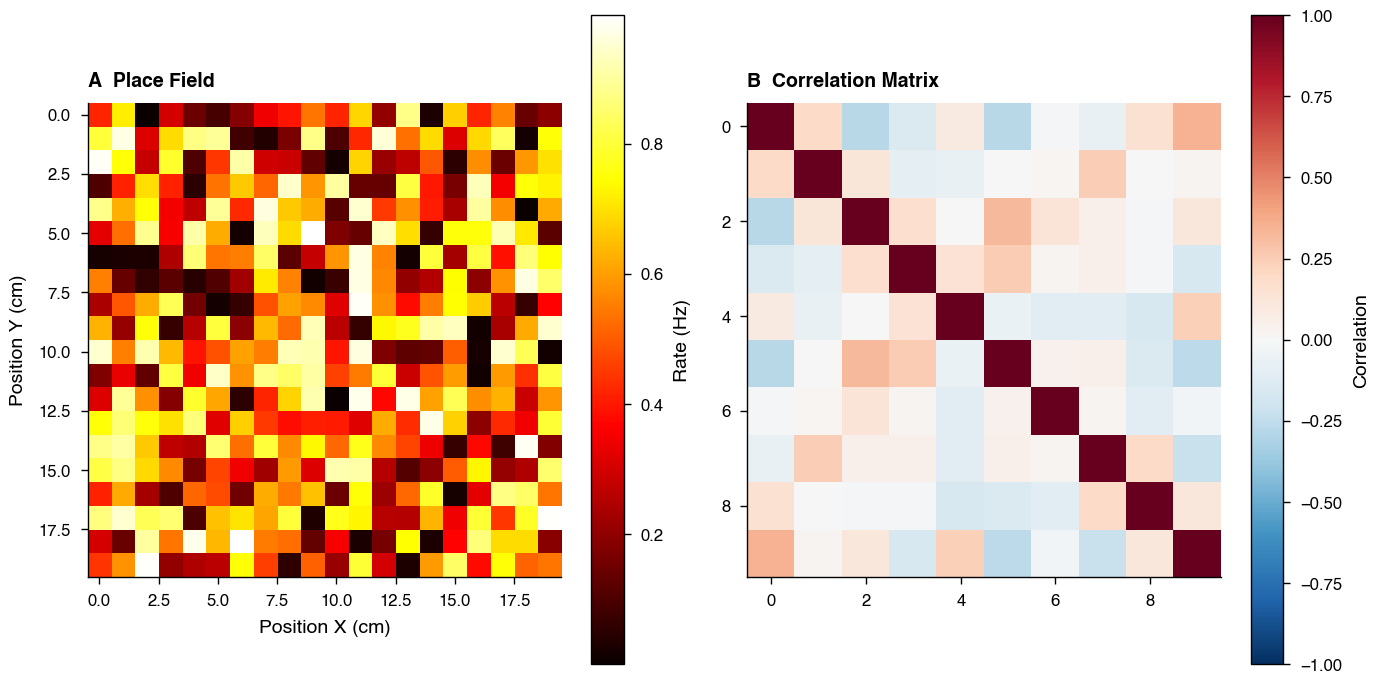

In [6]:
set_plotting_defaults("nature")

# Square figure — useful for place field maps, correlation matrices
fig, axes = plt.subplots(
    1, 2, figsize=set_size("nature_double", ratio=1.0, subplots=(1, 2)), dpi=200
)

np.random.seed(1)
place_field = np.random.rand(20, 20)
corr_matrix = np.corrcoef(np.random.rand(10, 50))

# Panel A — place field heatmap
im1 = axes[0].imshow(place_field, cmap="hot", aspect="equal")
axes[0].set_xlabel("Position X (cm)")
axes[0].set_ylabel("Position Y (cm)")
axes[0].set_title("A  Place Field", loc="left", fontweight="bold")
plt.colorbar(im1, ax=axes[0], label="Rate (Hz)")

# Panel B — correlation matrix
im2 = axes[1].imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
axes[1].set_title("B  Correlation Matrix", loc="left", fontweight="bold")
plt.colorbar(im2, ax=axes[1], label="Correlation")

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("nature_square.svg")
plt.show()

The default golden ratio (`~0.618`) is ideal for line plots, but `ratio=1.0` gives square panels which is better for spatial maps and matrices.

---
## 5. Word Workflow

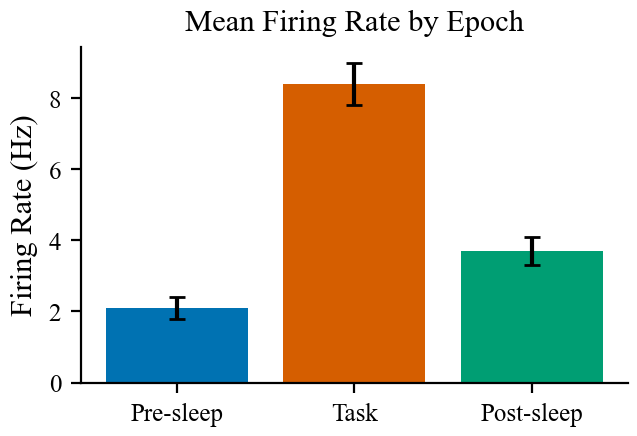

In [7]:
set_plotting_defaults("word")

# single_col maps to nature_single width — good default for Word figures
fig, ax = plt.subplots(figsize=set_size("single_col"), dpi=200)

np.random.seed(3)
epochs = ["Pre-sleep", "Task", "Post-sleep"]
means = [2.1, 8.4, 3.7]
sems = [0.3, 0.6, 0.4]

ax.bar(epochs, means, yerr=sems, capsize=3, color=["#0072B2", "#D55E00", "#009E73"])
ax.set_ylabel("Firing Rate (Hz)")
ax.set_title("Mean Firing Rate by Epoch")

if SAVE_FIG:
    fig.savefig("word_bar.svg")
plt.show()

---
## 6. LaTeX Workflow

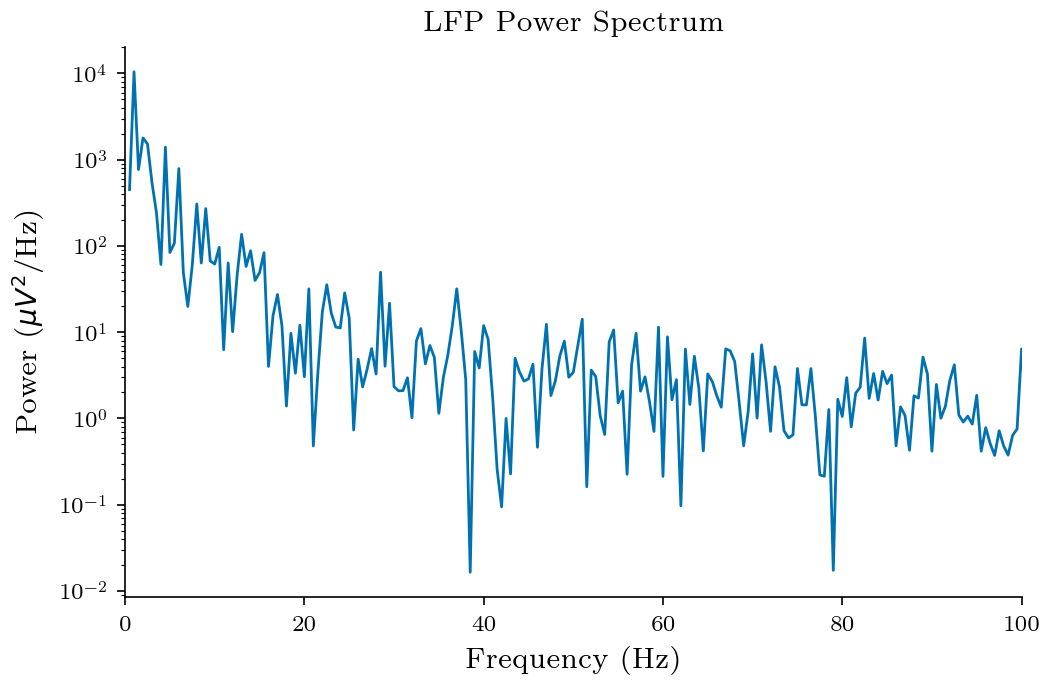

In [8]:
set_plotting_defaults("latex")

# textwidth matches \textwidth in a standard article class document
fig, ax = plt.subplots(figsize=set_size("textwidth"), dpi=200)

np.random.seed(5)
t = np.linspace(0, 2, 500)
theta = np.cumsum(np.random.randn(500)) * 0.1
power = np.abs(np.fft.rfft(theta)) ** 2
freqs = np.fft.rfftfreq(500, d=1 / 250)

ax.semilogy(freqs[1:], power[1:])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power ($\\mu V^2$/Hz)")
ax.set_title("LFP Power Spectrum")
ax.set_xlim(0, 100)

if SAVE_FIG:
    fig.savefig("latex_spectrum.svg")
plt.show()

For half-width figures in a LaTeX document (e.g. two figures side by side with `\includegraphics[width=0.5\textwidth]`):

```python
fig, ax = plt.subplots(figsize=set_size("textwidth", fraction=0.5))
```

---
## 7. Comparing Workflows Side by Side

To make font differences visible in a single figure, this demo applies workflow-specific font families directly to each panel (instead of relying only on global style settings).

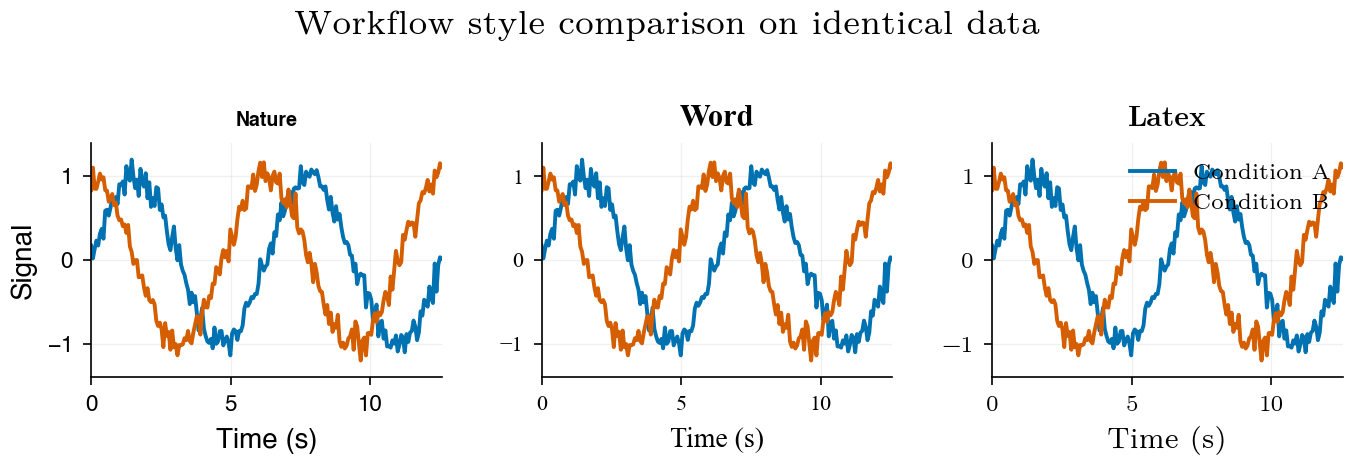

In [9]:
np.random.seed(7)
x = np.linspace(0, 4 * np.pi, 200)
y1 = np.sin(x) + np.random.normal(0, 0.1, 200)
y2 = np.cos(x) + np.random.normal(0, 0.1, 200)

workflows = ["nature", "word", "latex"]
demo_fonts = {
    "nature": "Helvetica",
    "word": "Times New Roman",
    "latex": "Latin Modern Roman",
}
ylim = (min(y1.min(), y2.min()) - 0.2, max(y1.max(), y2.max()) + 0.2)

fig, axes = plt.subplots(
    1, 3, figsize=set_size("nature_double", subplots=(1, 3), ratio=1), dpi=200
)

for ax, workflow in zip(axes, workflows):
    set_plotting_defaults(workflow)
    font = demo_fonts[workflow]

    ax.plot(x, y1, label="Condition A", lw=1.4)
    ax.plot(x, y2, label="Condition B", lw=1.4)
    ax.set_title(workflow.capitalize(), fontweight="bold", fontfamily=font)
    ax.set_xlabel("Time (s)", fontfamily=font)
    ax.set_ylim(*ylim)
    ax.margins(x=0)
    ax.grid(alpha=0.18, lw=0.5)

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily(font)

axes[0].set_ylabel("Signal", fontfamily=demo_fonts[workflows[0]])

legend = axes[-1].legend(frameon=False, loc="upper right", bbox_to_anchor=(1.02, 1.0))
for text in legend.get_texts():
    text.set_fontfamily(demo_fonts[workflows[-1]])

    fig.suptitle("Workflow style comparison on identical data", y=1.01)
fig.tight_layout()

if SAVE_FIG:
    fig.savefig("compare_workflows.svg", bbox_inches="tight")
plt.show()

---
## 8. Passing a Custom Width

If your journal has a specific column width not in the presets, pass the width in points directly. To convert from mm: `width_pt = width_mm * 2.8346`.

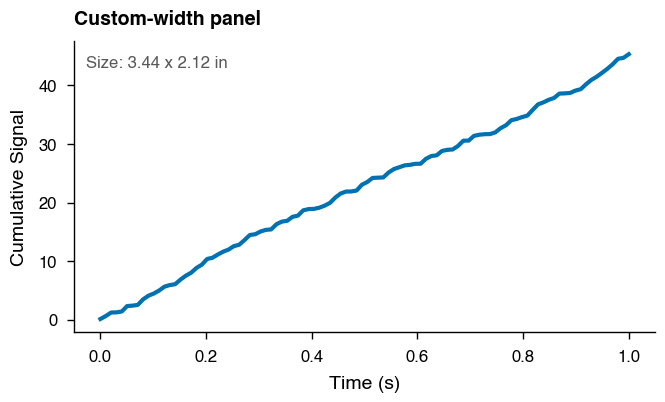

In [10]:
set_plotting_defaults("nature")

# eLife single column: 87.6 mm -> points
elife_single_pt = 87.6 * 2.8346
fig_w, fig_h = set_size(elife_single_pt)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=200)
trace = np.random.default_rng(11).random(100).cumsum()
ax.plot(np.linspace(0, 1, 100), trace, lw=1.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Cumulative Signal")
ax.set_title("Custom-width panel", loc="left", fontweight="bold")
ax.text(
    0.02,
    0.95,
    f"Size: {fig_w:.2f} x {fig_h:.2f} in",
    transform=ax.transAxes,
    va="top",
    fontsize=6,
    color="0.35",
)

fig.tight_layout()
plt.show()

---
## 9. Dark Theme with `neuro_py_dark`

For talks, posters, or dark slide decks, you can apply the provided `neuro_py_dark.mplstyle` file in a local style context without changing the rest of the notebook defaults.

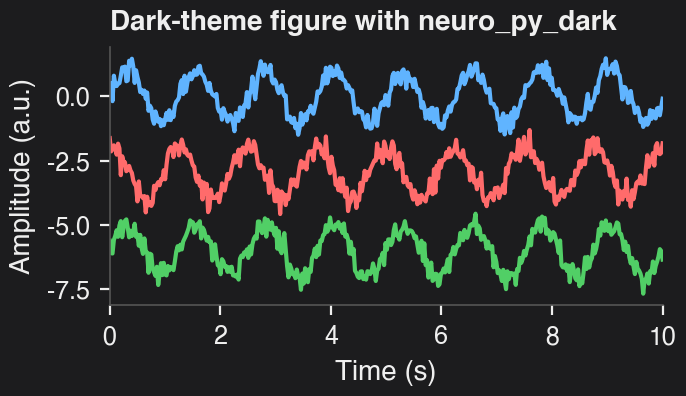

In [11]:
set_plotting_defaults("dark")

fig, ax = plt.subplots(figsize=set_size("nature_single"), dpi=200)
rng = np.random.default_rng(21)
x = np.linspace(0, 10, 400)
signal = np.sin(2 * np.pi * 0.8 * x) + 0.25 * rng.normal(size=x.size)
ax.plot(x, signal, label="LFP-like trace")
signal = np.cos(2 * np.pi * 0.8 * x) + 0.25 * rng.normal(size=x.size)
ax.plot(x, signal - 3, label="LFP-like trace")
signal = np.sin(2 * np.pi * 0.8 * x) + 0.25 * rng.normal(size=x.size)
ax.plot(x, signal - 6, label="LFP-like trace")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (a.u.)")
ax.set_title("Dark-theme figure with neuro_py_dark", loc="left", fontweight="bold")
ax.margins(x=0)

fig.tight_layout()
if SAVE_FIG:
    fig.savefig("dark_style_demo.svg", bbox_inches="tight")
plt.show()

---
## 10. Notebook Display Scaling

Modern notebook frontends may render Matplotlib figures at their logical figure size rather than their raw PNG pixel size. In those environments, increasing `dpi` improves sharpness but does not make the figure appear larger on screen.

Use `show_scaled(...)` when you want a larger notebook display while keeping the underlying `fig` at its original publication size for `savefig(...)`.

Use `scale_figsize(...)` together with `figure_scale(...)` when you actually want to create a larger scaled figure object.

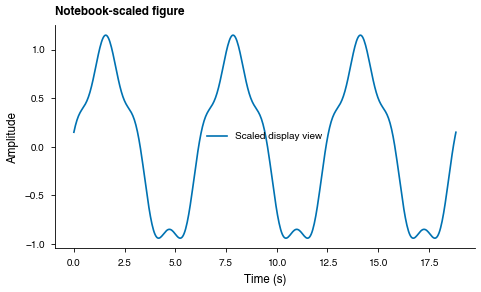


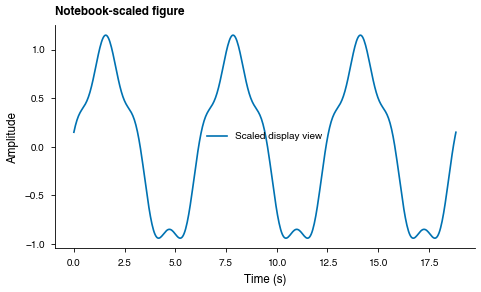

In [12]:
set_plotting_defaults("nature")

x = np.linspace(0, 6 * np.pi, 500)
y = np.sin(x) + 0.15 * np.cos(4 * x)

fig, ax = plt.subplots(
    figsize=set_size("paper", fraction=0.5, subplots=(1, 1)),
    dpi=120,
)
ax.plot(x, y, label="Scaled display view")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Notebook-scaled figure", loc="left", fontweight="bold")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

show_scaled(fig, scale=1.75)

---
## Quick Recipe Card

Use this as a copy/paste checklist when preparing final figures:

```python
from neuro_py.plotting.figure_helpers import show_scaled

# 1) Pick your destination workflow
set_plotting_defaults("nature")   # or "word", "latex"

# 2) Match figure width to target layout
fig, ax = plt.subplots(figsize=set_size("nature_single"))

# 3) Multi-panel layout (height auto-adjusts)
fig, axes = plt.subplots(2, 3, figsize=set_size("nature_double", subplots=(2, 3)))

# 4) For maps/matrices, force square axes
fig, ax = plt.subplots(figsize=set_size("nature_single", ratio=1.0))

# 5) Half-width panel for insets
fig, ax = plt.subplots(figsize=set_size("nature_double", fraction=0.5))

# 6) Optional: scale for notebook display while preserving proportions
scale = 1.5
show_scaled(fig, scale=scale)

# 7) Save vector output for publication
fig.savefig("figure.svg", bbox_inches="tight")
```

Tip: if labels look too small/large in your manuscript, verify that the figure is inserted at its intended physical width (not scaled in the editor).